# Pancreatic Cancer Prediction in Classification

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings as ws
ws.filterwarnings('ignore')


from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ttest_ind




# Read the CSV file and Analysis the data and which going to output

In [20]:
dataset = pd.read_csv("Pancreatic_Cancer.csv")

# First - Data Cleaning

In [21]:
print("No of Rows and Columns: ",dataset.shape)
print("Duplicate values: ", dataset.duplicated().sum())
null_columns = dataset.isnull().sum()
print("Missing Values: ", null_columns[null_columns > 0])
# ---------------- Drop ID column ----------------
dataset = dataset.drop(columns=['Patient_ID'])

No of Rows and Columns:  (60000, 132)
Duplicate values:  0
Missing Values:  Series([], dtype: int64)


# Convert the all categorical data into numerical data

In [22]:
# ---------------- Encode Target (Ordinal - has natural order) ----------------
# One-Hot Encoding for categorical data - Newyork, Texas, New jersey
# Label Encoding-  Binary categories like yes/No, True/False
# Ordinal Encoding - low, high, medium
# Here predict different stages of disease present or not. use Ordinal Encoding
stageOrder = [['Healthy', 'High Risk', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']]
encoder = OrdinalEncoder(categories=stageOrder)
dataset['Cancer_Stage'] = encoder.fit_transform(dataset[['Cancer_Stage']])

# ---------------- Encode remaining categorical features (One-Hot encoding) ----------------
dataset = pd.get_dummies(dataset, drop_first=True, dtype=int)

# Split input and Output and Finally Split the Train and Test Set

In [23]:
independent = dataset.drop(columns=["Cancer_Stage"], axis=1)
dependent = dataset["Cancer_Stage"]

#stratify=dependent  preserves the target class distribution in both the training and testing datasets.

X_train, X_test, Y_train, Y_test = train_test_split(
    independent, dependent, test_size=0.30, random_state=0, stratify=dependent
)

# Check the Output Class and how much balance or not balanced

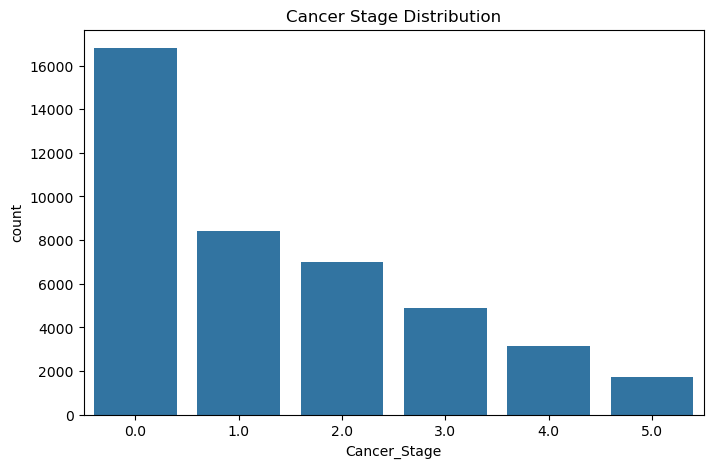

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x="Cancer_Stage", data=Y_train.to_frame())
plt.title("Cancer Stage Distribution")
plt.show()

# Based that images, the output having 6 class, which are 'Healthy', 'High Risk', 'Stage I', 'Stage II', 'Stage III', 'Stage IV' and make it balanced one using smote technique

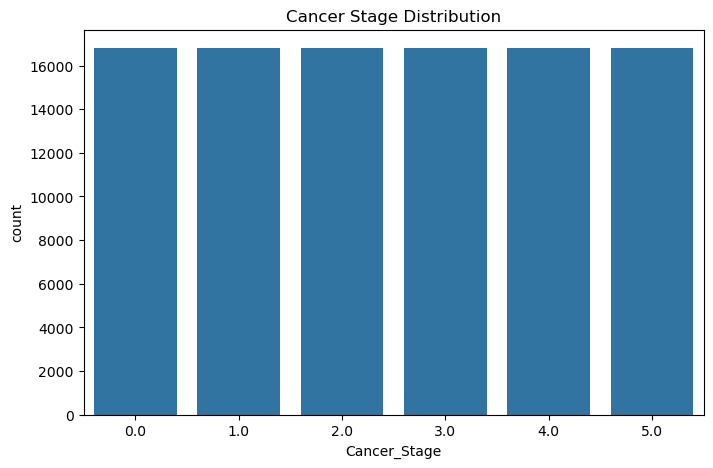

In [25]:
# ---------------- Handle Class Imbalance (train set only) ----------------
smote = SMOTE(random_state=42)
X_train_balance, Y_train_balance = smote.fit_resample(X_train, Y_train)

plt.figure(figsize=(8,5))
sns.countplot(x="Cancer_Stage", data=Y_train_balance.to_frame())
plt.title("Cancer Stage Distribution")
plt.show()


# Based that images, the output having 6 class are balanced one using smote technique and choose the best feature from this and recreate the input and output and split the train and test set again from new input and output

In [26]:
# ---------------- Feature Selection ----------------
selector = SelectKBest(score_func=f_classif, k=7)
selector.fit_transform(X_train_balance, Y_train_balance)

# Get the names of the selected columns
selected_features = independent.columns[selector.get_support()]
print(selected_features)

X =dataset[selected_features]
Y =dataset["Cancer_Stage"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=0, stratify=Y
)

Index(['Demographic_3', 'Lifestyle_7', 'Symptom_20', 'Lab_14', 'Imaging_11',
       'Imaging_12', 'Genetic_4'],
      dtype='object')


# Selected Feature based Univariate and Bivariate analaysis

In [27]:
# ---------------- Identify categorical columns (before encoding) ----------------
CDataset =dataset[selected_features.tolist() + ["Cancer_Stage"]]
quali_cols = CDataset.select_dtypes(include='object').columns.tolist()
quan_cols = CDataset.select_dtypes(exclude='object').columns.tolist()
CDataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Demographic_3  60000 non-null  float64
 1   Lifestyle_7    60000 non-null  float64
 2   Symptom_20     60000 non-null  float64
 3   Lab_14         60000 non-null  float64
 4   Imaging_11     60000 non-null  float64
 5   Imaging_12     60000 non-null  float64
 6   Genetic_4      60000 non-null  float64
 7   Cancer_Stage   60000 non-null  float64
dtypes: float64(8)
memory usage: 3.7 MB


In [28]:
CDataset.corr(numeric_only=True)

,Demographic_3,Lifestyle_7,Symptom_20,Lab_14,Imaging_11,Imaging_12,Genetic_4,Cancer_Stage
Demographic_3,1.000000,0.304512,0.308511,0.307275,0.314489,0.308625,0.310609,0.557092
Lifestyle_7,0.304512,1.000000,0.310745,0.305866,0.306652,0.305332,0.311939,0.556230
Symptom_20,0.308511,0.310745,1.000000,0.303232,0.308057,0.311675,0.310056,0.552573
Lab_14,0.307275,0.305866,0.303232,1.000000,0.305552,0.306859,0.307560,0.552566
Imaging_11,0.314489,0.306652,0.308057,0.305552,1.000000,0.309071,0.313200,0.553482
Imaging_12,0.308625,0.305332,0.311675,0.306859,0.309071,1.000000,0.322306,0.560100
Genetic_4,0.310609,0.311939,0.310056,0.307560,0.313200,0.322306,1.000000,0.558293
Cancer_Stage,0.557092,0.556230,0.552573,0.552566,0.553482,0.560100,0.558293,1.000000


In [29]:
CDataset.cov(numeric_only=True)

,Demographic_3,Lifestyle_7,Symptom_20,Lab_14,Imaging_11,Imaging_12,Genetic_4,Cancer_Stage
Demographic_3,635.644589,193.332829,195.612335,195.070077,199.412395,196.149159,197.540040,20.934859
Lifestyle_7,193.332829,634.142306,196.796075,193.946343,194.212874,193.826563,198.151057,20.877753
Symptom_20,195.612335,196.796075,632.465828,192.021451,194.844834,197.591293,196.694755,20.713073
Lab_14,195.070077,193.946343,192.021451,634.034370,193.500218,194.779352,195.352952,20.738477
Imaging_11,199.412395,194.212874,194.844834,193.500218,632.526647,195.950091,198.698379,20.748158
Imaging_12,196.149159,193.826563,197.591293,194.779352,195.950091,635.470977,204.950931,21.045021
Genetic_4,197.540040,198.151057,196.694755,195.352952,198.698379,204.950931,636.308323,20.990971
Cancer_Stage,20.934859,20.877753,20.713073,20.738477,20.748158,21.045021,20.990971,2.221634


In [30]:
# ---------------- Calculate Central Dependency ----------------
X_selected = CDataset.drop(columns=["Cancer_Stage"]).columns
descriptive = pd.DataFrame(index=["Mean", "Median", "Mode", "Q1:25%", "Q2:50%", "Q3:75%","Max", "IQR", "1.5Rule","Lesser","Greater","Min","Max","Skew","Kurtosis",'Var', 'StdVar',"Values","Frequency", "Relative Frequency", "Cusum Frequency"], columns=X_selected)
for colName in X_selected:            
     descriptive[colName]["Mean"]= CDataset[colName].mean()
     descriptive[colName]["Median"]=  CDataset[colName].median()
     descriptive[colName]["Mode"]=  CDataset[colName].mode()[0]
     descriptive[colName]["Q1:25%"]=  CDataset.describe()[colName]["25%"]
     descriptive[colName]["Q2:50%"]= CDataset.describe()[colName]["50%"]
     descriptive[colName]["Q3:75%"]= CDataset.describe()[colName]["75%"]             
     descriptive[colName]["Max"]=  CDataset.describe()[colName]["max"]
     descriptive[colName]["IQR"]=  descriptive[colName]["Q3:75%"] - descriptive[colName]["Q1:25%"]
     descriptive[colName]["1.5Rule"] = 1.5 * descriptive[colName]["IQR"]
     descriptive[colName]["Lesser"] =descriptive[colName]["Q1:25%"]-descriptive[colName]["1.5Rule"]
     descriptive[colName]["Greater"] = descriptive[colName]["Q3:75%"]+ descriptive[colName]["1.5Rule"]
     descriptive[colName]["Min"]=CDataset[colName].min()
     descriptive[colName]["Max"]=CDataset[colName].max()
     descriptive[colName]["Skew"]=CDataset[colName].skew()
     descriptive[colName]["Kurtosis"]=CDataset[colName].kurtosis()
     descriptive[colName]["Var"]=CDataset[colName].var()
     descriptive[colName]["StdVar"]=CDataset[colName].std()
     descriptive[colName]["Values"] = CDataset[colName].value_counts().index
     descriptive[colName]["Frequency"] = CDataset[colName].value_counts().values
     tableLength = len( descriptive[colName]["Values"])
     descriptive[colName]["Relative Frequency"]= descriptive[colName]["Frequency"]/tableLength
     descriptive [colName]["Cusum Frequency"]= descriptive[colName]["Relative Frequency"].cumsum()
descriptive

,Demographic_3,Lifestyle_7,Symptom_20,Lab_14,Imaging_11,Imaging_12,Genetic_4
Mean,33.544614,33.445855,33.366075,33.386057,33.497373,33.516328,33.566212
Median,28.5,28.38,28.32,28.365,28.57,28.48,28.59
Mode,17.34,1.39,6.82,38.58,9.59,35.74,38.02
Q1:25%,14.33,14.16,14.15,14.15,14.22,14.13,14.29
Q2:50%,28.5,28.38,28.32,28.365,28.57,28.48,28.59
Q3:75%,46.4025,46.41,46.0025,46.1,46.3625,46.36,46.53
Max,126.97,126.93,126.99,126.89,127.0,126.98,126.99
IQR,32.0725,32.25,31.8525,31.95,32.1425,32.23,32.24
1.5Rule,48.10875,48.375,47.77875,47.925,48.21375,48.345,48.36
Lesser,-33.77875,-34.215,-33.62875,-33.775,-33.99375,-34.215,-34.07


In [31]:
def calc_vif(X):
    
    #Creates an empty DataFrame to store the results. 
    vif= pd.DataFrame()
    # Gets all column names from X.
    vif["Vaiables"]=X.columns
    #Shapes return row and columns
    #shape[1] picks out just the number of columns.
    # x.values - Converts the DataFrame X into a plain NumPy array
    # variance_inflation_factor(X.values, i) - Calculates the VIF for the column at index i by regressing it against all the other independent variables.
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return(vif)

In [34]:
# ---------------- Calculates the VIF for detect the multicolinearity----------------
calc_vif(CDataset.iloc[:, :].corr(numeric_only=True))

,Vaiables,VIF
0,Demographic_3,5.201944
1,Lifestyle_7,5.189113
2,Symptom_20,5.051308
3,Lab_14,5.079207
4,Imaging_11,5.074164
5,Imaging_12,5.289837
6,Genetic_4,5.203265
7,Cancer_Stage,67.972742


In [37]:
Symptom1= CDataset[CDataset["Cancer_Stage"]==2.0]["Demographic_3"]
Symptom2=CDataset[CDataset["Cancer_Stage"]==2.0]["Imaging_12"]
ttest_ind(Symptom1, Symptom2)
# pvalue >0.05. here significant differnce avaiables

TtestResult(statistic=np.float64(0.07879549977773917), pvalue=np.float64(0.9371960719503526), df=np.float64(19998.0))